# StrokeGuard AI — Phase 2: Exploratory Data Analysis (EDA)

Goal: understand the data before touching any model. For every chart below, write a **1-2 line observation in your own words** in the markdown cell underneath it. This is what you'll be defending in your presentation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Make sure the images folder exists for saving charts
os.makedirs('../images', exist_ok=True)


## Load the Dataset

In [6]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 1. Basic Info
Check the shape, column types, and a statistical summary.

In [7]:
print('Shape:', df.shape)
df.info()


Shape: (5110, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [8]:
df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 2. Missing Values
Which columns have missing data, and how much?

bmi    201
dtype: int64


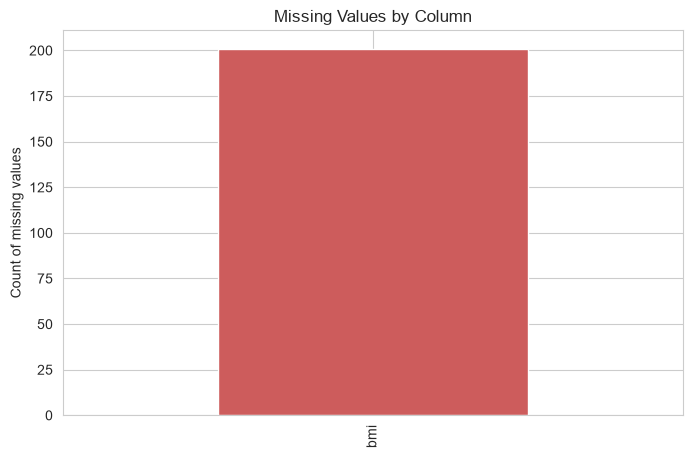

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

missing.plot(kind='bar', color='indianred')
plt.title('Missing Values by Column')
plt.ylabel('Count of missing values')
plt.show()


**Your observation:** _(e.g., which column is missing data, and roughly what % of rows does it affect?)_

> 

## 3. Class Imbalance (Target Variable: `stroke`)
How many patients had a stroke vs. didn't?

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


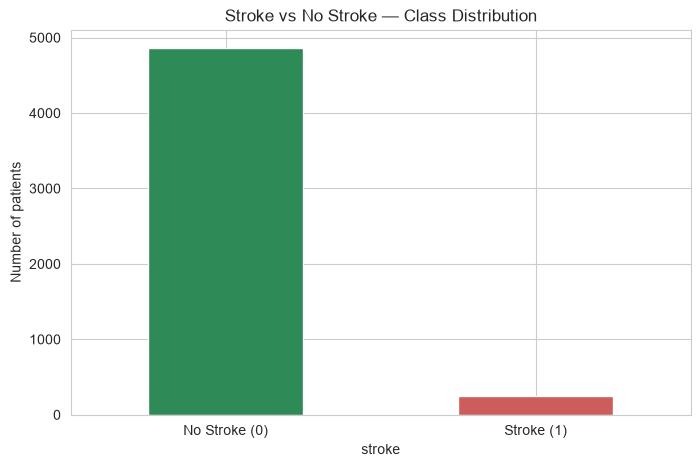

In [10]:
counts = df['stroke'].value_counts()
percentages = df['stroke'].value_counts(normalize=True) * 100
print(counts)
print(percentages.round(2))

counts.plot(kind='bar', color=['seagreen', 'indianred'])
plt.title('Stroke vs No Stroke — Class Distribution')
plt.xticks([0, 1], ['No Stroke (0)', 'Stroke (1)'], rotation=0)
plt.ylabel('Number of patients')
plt.show()


**Your observation:** _(Why can't we just use accuracy on data like this?)_

> 

## 4. Age Distribution
What does the age spread of patients look like?

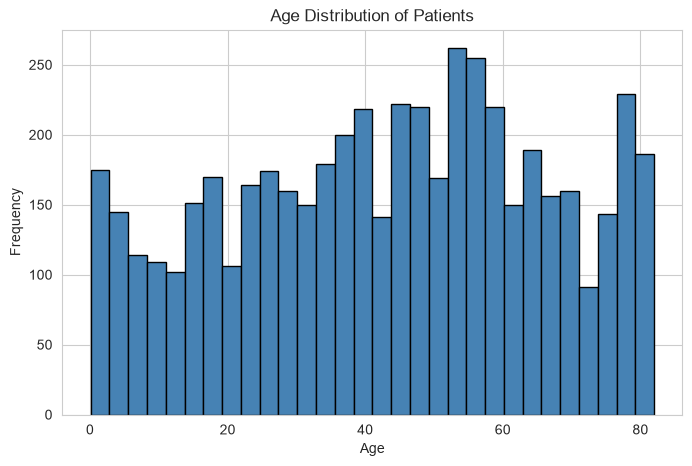

In [11]:
df['age'].plot(kind='hist', bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.savefig('../images/age_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Is the dataset mostly younger or older patients?)_

> 

## 5. Stroke Rate by Age Group
Does stroke risk increase with age?

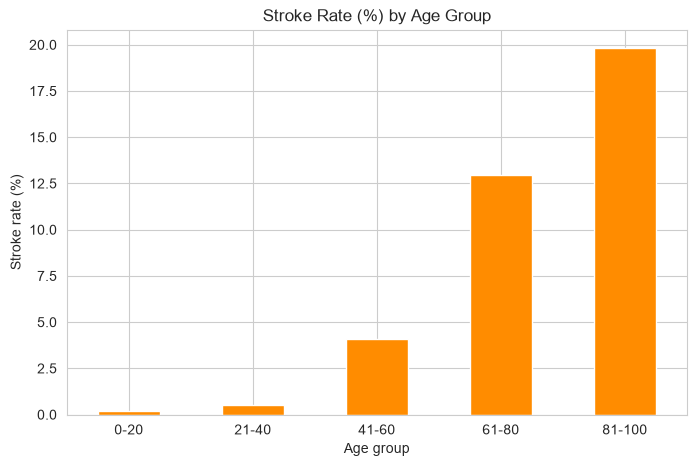

In [12]:
df['age_group'] = pd.cut(df['age'], bins=[0,20,40,60,80,100],
                          labels=['0-20','21-40','41-60','61-80','81-100'])

stroke_by_age = df.groupby('age_group')['stroke'].mean() * 100
stroke_by_age.plot(kind='bar', color='darkorange')
plt.title('Stroke Rate (%) by Age Group')
plt.ylabel('Stroke rate (%)')
plt.xlabel('Age group')
plt.xticks(rotation=0)
plt.savefig('../images/stroke_rate_by_age.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(At what age group does risk start climbing sharply?)_

> 

## 6. Stroke Rate by Glucose Level
Does higher blood glucose relate to higher stroke risk?

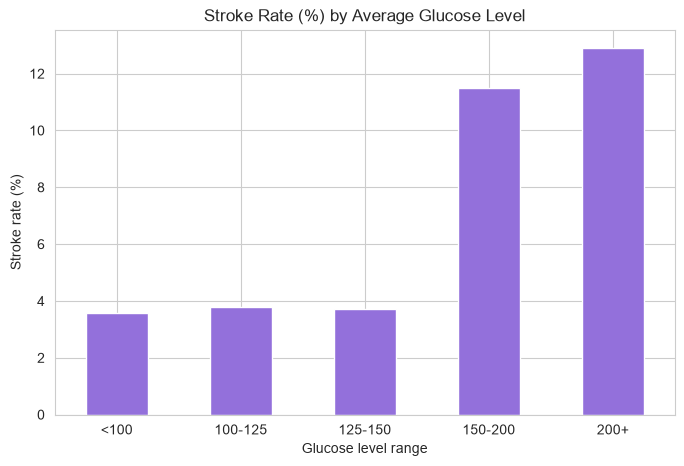

In [13]:
df['glucose_group'] = pd.cut(df['avg_glucose_level'], bins=[0,100,125,150,200,300],
                              labels=['<100','100-125','125-150','150-200','200+'])

stroke_by_glucose = df.groupby('glucose_group')['stroke'].mean() * 100
stroke_by_glucose.plot(kind='bar', color='mediumpurple')
plt.title('Stroke Rate (%) by Average Glucose Level')
plt.ylabel('Stroke rate (%)')
plt.xlabel('Glucose level range')
plt.xticks(rotation=0)
plt.savefig('../images/stroke_rate_by_glucose.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Is there a clear pattern, or is it noisy?)_

> 

## 7. Stroke Rate by Hypertension and Heart Disease
Do these pre-existing conditions raise stroke risk?

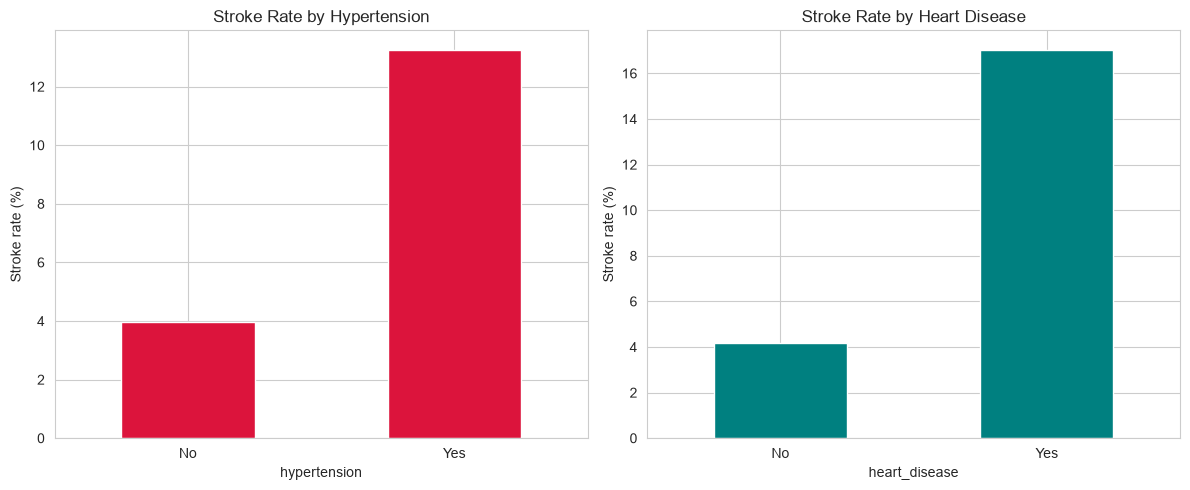

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('hypertension')['stroke'].mean().mul(100).plot(kind='bar', ax=axes[0], color='crimson')
axes[0].set_title('Stroke Rate by Hypertension')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0].set_ylabel('Stroke rate (%)')

df.groupby('heart_disease')['stroke'].mean().mul(100).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Stroke Rate by Heart Disease')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].set_ylabel('Stroke rate (%)')

plt.tight_layout()
plt.savefig('../images/stroke_rate_hypertension_heartdisease.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(How much more at-risk are patients with these conditions?)_

> 

## 8. Correlation Heatmap
How do the numeric features relate to each other and to stroke?

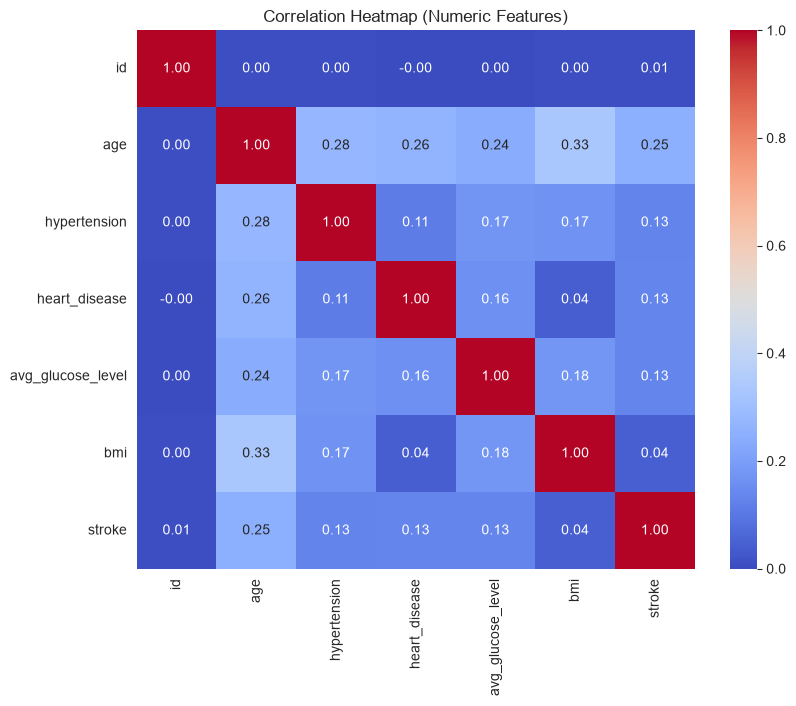

In [15]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


**Your observation:** _(Which features correlate most with `stroke`? Any surprises?)_

> 

## Summary of Key Insights

Write 3-4 bullet points, in your own words, summarizing what this EDA taught you. This becomes your presentation talking points.

- 
- 
- 
- 